In [16]:
import sys
import os
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# project root 
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
import wfdb

from utils.preprocessing import bandpass_filter, extract_beats, preprocess_for_inference
from utils.dataset import load_ecg_data
from models.cnn_model import build_cnn
from models.cnn_lstm_model import build_cnn_lstm
from predict import predict_ecg 



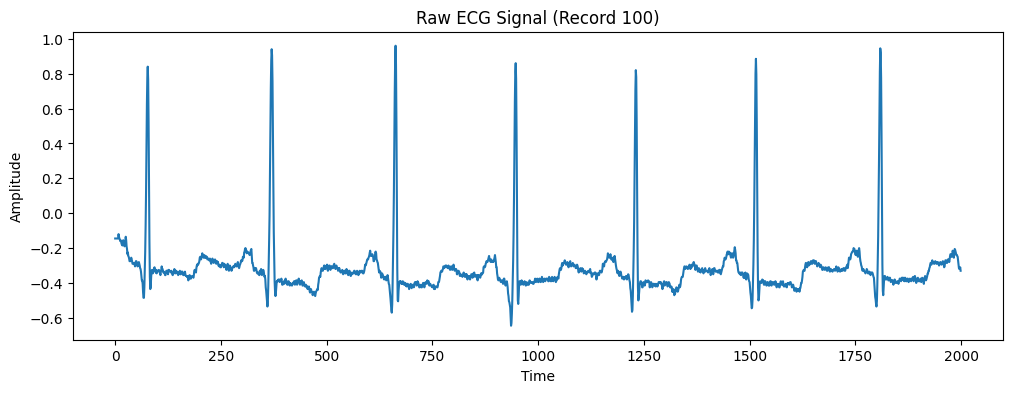

In [4]:
record_id = '100'
record = wfdb.rdrecord(record_id, pn_dir='mitdb')
annotation = wfdb.rdann(record_id, 'atr', pn_dir='mitdb')

raw_signal = record.p_signal[:, 0]

plt.figure(figsize=(12,4))
plt.plot(raw_signal[:2000])
plt.title(f"Raw ECG Signal (Record {record_id})")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()


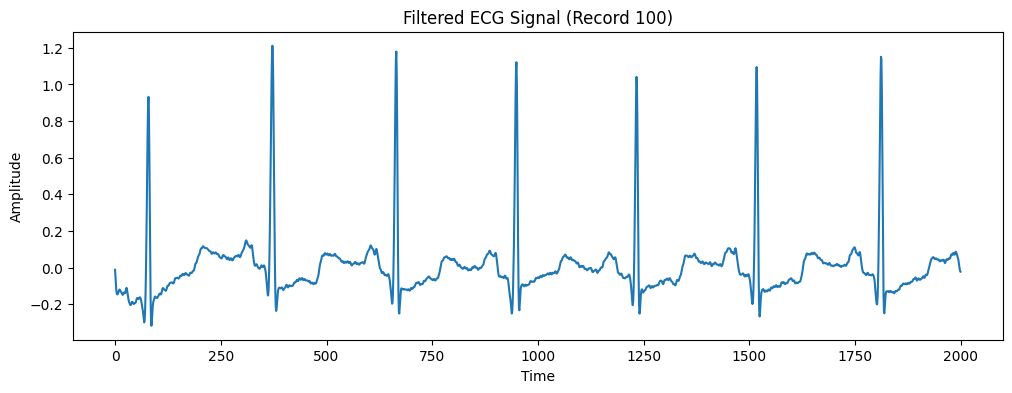

In [5]:
filtered_signal = bandpass_filter(raw_signal)

plt.figure(figsize=(12,4))
plt.plot(filtered_signal[:2000])
plt.title(f"Filtered ECG Signal (Record {record_id})")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()


In [6]:
X, y = extract_beats(filtered_signal, annotation)
print(f"Shape of extracted beats: {X.shape}")
print(f"Shape of labels: {y.shape}")


Shape of extracted beats: (2238, 360)
Shape of labels: (2238,)


In [9]:
encoder = LabelEncoder()
y_enc = encoder.fit_transform(y)
y_cat = to_categorical(y_enc)

X = X[..., np.newaxis]  # Add channel dimension
print(f"Shape after adding channel: {X.shape}")


Shape after adding channel: (2238, 360, 1)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42
)

print(f"Train samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")


Train samples: 1790, Test samples: 448


In [12]:
input_shape = (360, 1)
num_classes = y_cat.shape[1]

model = build_cnn_lstm(input_shape, num_classes)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    shuffle=True,
    verbose=1
)


c:\Users\BASHEERA SULTANA\anaconda3\envs\venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 356, 64)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 178, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,698 (147.26 KB)

 Trainable params: 37,698 (147.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.9826 - loss: 0.1860 - val_accuracy: 1.0000 - val_loss: 3.5763e-07
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.9994 - loss: 0.0095 - val_accuracy: 1.0000 - val_loss: 9.4968e-07
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.9994 - loss: 0.0091 - val_accuracy: 1.0000 - val_loss: 2.6655e-05
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.9994 - loss: 0.0085 - val_accuracy: 1.0000 - val_loss: 3.0840e-05
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.9994 - loss: 0.0086 - val_accuracy: 1.0000 - val_loss: 2.0884e-04
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.9994 - loss: 0.0063 - val_accuracy: 1.0000 - val_loss: 1.6407e-04
Epoch 7/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.9994 - loss: 0.0080 - val_accuracy: 1.0000 - val_loss: 1.0972e-04
Epoch 8/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.9994 - loss: 0.007

In [13]:
from utils.evaluation import evaluate_model

report = evaluate_model(model, X_test, y_test)
print("Classification Report:\n", report)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       448

    accuracy                           1.00       448
   macro avg       1.00      1.00      1.00       448
weighted avg       1.00      1.00      1.00       448



In [14]:
model.save("models/ecg_cnn_lstm.h5")

import joblib
joblib.dump(encoder, "models/label_encoder.pkl")
print("Model and Label Encoder saved!")


Model and Label Encoder saved!


In [17]:
# Take the first test beat
sample_signal = X_test[0]

# Preprocess for inference
processed = preprocess_for_inference(sample_signal.flatten())
pred_class, confidence, report = predict_ecg(processed)

print(f"Predicted class: {pred_class}")
print(f"Confidence: {confidence}")
print(f"Report: {report}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
Predicted class: N
Confidence: 1.0
Report: Normal ECG detected.
